In [7]:
import sys
print(sys.executable)  # покажет путь к интерпретатору

c:\Users\Артур\AppData\Local\Programs\Python\Python310\python.exe


In [1]:
import asyncio
import sys

# ← ОБЯЗАТЕЛЬНО для Windows + Jupyter + Playwright
if sys.platform == "win32":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

import json
import csv
import re
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright

In [16]:
import asyncio
import csv
import re
import sys
import threading
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright

BASE_URL = "https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam"
MAX_PAGES = 5
OUTPUT_FILE = r"C:\Users\Артур\.vscode\НОД\avito_commercial.csv"
HEADLESS = True


async def get_page_html(page, url: str) -> str:
    await page.goto(url, wait_until="domcontentloaded", timeout=60_000)
    try:
        await page.wait_for_selector('[data-marker="item"]', timeout=15_000)
    except Exception:
        print(f"  [!] Карточки не появились на {url}")
    await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
    await asyncio.sleep(2)
    return await page.content()


def parse_listings(html: str) -> list:
    soup = BeautifulSoup(html, "html.parser")
    items = soup.find_all("div", attrs={"data-marker": "item"})
    results = []
    for item in items:
        try:
            results.append(extract_listing_data(item))
        except Exception as e:
            print(f"  [!] Ошибка карточки: {e}")
    return results


def extract_listing_data(item) -> dict:

    # ── Заголовок и ссылка ────────────────────────────────────────────────
    title_tag = item.find("a", attrs={"data-marker": "item-title"})
    title = ""
    link = ""
    if title_tag:
        title = title_tag.get("title", "") or title_tag.get_text(strip=True)
        href = title_tag.get("href", "")
        link = "https://www.avito.ru" + href.split("?")[0]  # убираем ?context=...

    # ── Цена ──────────────────────────────────────────────────────────────
    price_tag = item.find("meta", attrs={"itemprop": "price"})
    if price_tag:
        price = price_tag.get("content", "")
    else:
        price_block = item.find("p", attrs={"data-marker": "item-price"})
        price = price_block.get_text(strip=True) if price_block else ""

    # ── Адрес ─────────────────────────────────────────────────────────────
    street = ""
    metro = ""
    metro_time = ""

    geo_block = item.find(attrs={"data-marker": "item-address"})
    if geo_block:
        all_p = geo_block.find_all("p")

        # ── Улица: первый <p> ─────────────────────────────────────────────
        # Структура: <p><span title=""><span>иконка SVG</span>текст улицы</span></p>
        if len(all_p) >= 1:
            outer_span = all_p[0].find("span", title=True)
            if outer_span:
                # get_text даст "текст улицы" без SVG-мусора
                street = outer_span.get_text(strip=True)

        # ── Метро: второй <p> ─────────────────────────────────────────────
        # Структура: <p>
        #   <span class="geo-icons-...">  ← [0] иконки линий, пропускаем
        #   <span>Киевская</span>         ← [1] название станции
        #   <span>                        ← [2] содержит время
        #     <span>, </span>
        #     <span>11–15 мин.</span>
        #   </span>
        # </p>
        if len(all_p) >= 2:
            # find_all только прямых дочерних span (recursive=False)
            top_spans = all_p[1].find_all("span", recursive=False)
            # top_spans[0] — иконки (geo-icons-...), пропускаем
            # top_spans[1] — название станции
            # top_spans[2] — время (содержит вложенные span)
            if len(top_spans) >= 2:
                metro = top_spans[1].get_text(strip=True)        # "Киевская"
            if len(top_spans) >= 3:
                # Внутри span времени: <span>, </span><span>11–15 мин.</span>
                time_spans = top_spans[2].find_all("span")
                metro_time = time_spans[-1].get_text(strip=True) # "11–15 мин."

    # ── Площадь из заголовка ──────────────────────────────────────────────
    area_match = re.search(r"(\d[\d,.]*)\s*м²", title)
    area = area_match.group(0) if area_match else ""

    # ── Дата ──────────────────────────────────────────────────────────────
    date_tag = item.find("p", attrs={"data-marker": "item-date"})
    date = date_tag.get_text(strip=True) if date_tag else ""

    return {
        "title":      title,
        "price":      price,
        "area":       area,
        "address":    street,
        "metro":      metro,
        "metro_time": metro_time,
        "date":       date,
        "url":        link,
    }


def save_to_csv(records: list, filepath: str):
    if not records:
        print("[!] Нет данных для сохранения")
        return
    # ← fieldnames точно совпадает с ключами словаря
    fieldnames = ["title", "price", "area", "address", "metro", "metro_time", "date", "url"]
    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(records)
    print(f"\n✓ Сохранено {len(records)} объявлений → {filepath}")


async def main():
    all_listings = []
    async with async_playwright() as p:
        CHROME_PATH = r"C:\Program Files\Google\Chrome\Application\chrome.exe"
        browser = await p.chromium.launch(
            headless=HEADLESS,
            executable_path=CHROME_PATH,
            args=["--no-sandbox", "--disable-blink-features=AutomationControlled"]
        )
        context = await browser.new_context(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0.0.0 Safari/537.36"
            ),
            viewport={"width": 1366, "height": 768},
            locale="ru-RU",
        )
        page = await context.new_page()
        await page.add_init_script(
            "Object.defineProperty(navigator, 'webdriver', {get: () => undefined});"
        )

        for page_num in range(1, MAX_PAGES + 1):
            url = BASE_URL if page_num == 1 else f"{BASE_URL}?p={page_num}"
            print(f"[{page_num}/{MAX_PAGES}] Парсим: {url}")
            html = await get_page_html(page, url)
            listings = parse_listings(html)
            if not listings:
                print(f"  → Объявления не найдены, стоп на стр. {page_num}")
                break
            print(f"  → Найдено {len(listings)} объявлений")
            all_listings.extend(listings)
            await asyncio.sleep(3)

        await browser.close()
    save_to_csv(all_listings, OUTPUT_FILE)


def run_in_thread():
    loop = asyncio.ProactorEventLoop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(main())
    loop.close()


thread = threading.Thread(target=run_in_thread)
thread.start()
thread.join()

[1/5] Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam
  [!] Карточки не появились на https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam
  → Найдено 50 объявлений
[2/5] Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=2
  → Найдено 50 объявлений
[3/5] Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=3
  → Найдено 50 объявлений
[4/5] Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=4
  → Найдено 50 объявлений
[5/5] Парсим: https://www.avito.ru/moskva/kommercheskaya_nedvizhimost/sdam?p=5
  → Найдено 50 объявлений

✓ Сохранено 250 объявлений → C:\Users\Артур\.vscode\НОД\avito_commercial.csv


KeyboardInterrupt: 

# Первичная очистка датафрейма

                                               title   price   area  \
0    10-118 м² в проходном месте на Тишинке в Москве  200000  118.0   
1                             Склад, 130 м² в Москве    1100  130.0   
2       Торговое помещение в аренду, 5.2 м² в Москве  150000    5.2   
3                             Офис, 58.8 м² в Москве   25000   58.8   
4            Свободного назначения, 57.6 м² в Москве  490000   57.6   
..                                               ...     ...    ...   
128                          Офис, 106.3 м² в Москве   49500  106.3   
129                             Офис, 15 м² в Москве   15000   15.0   
130                             Офис, 10 м² в Москве   40000   10.0   
131                           Офис, 23.4 м² в Москве   23400   23.4   
132                 Торговая площадь, 15 м² в Москве  190000   15.0   

                          address                   metro  metro_time  \
0    Большая Грузинская ул., 57с1             Белорусская   6–10 мин.   
1

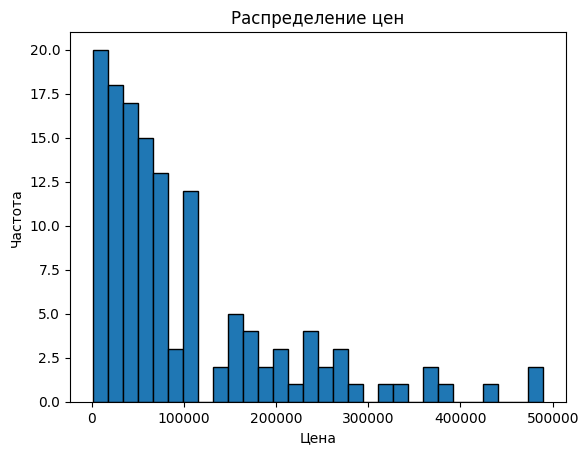

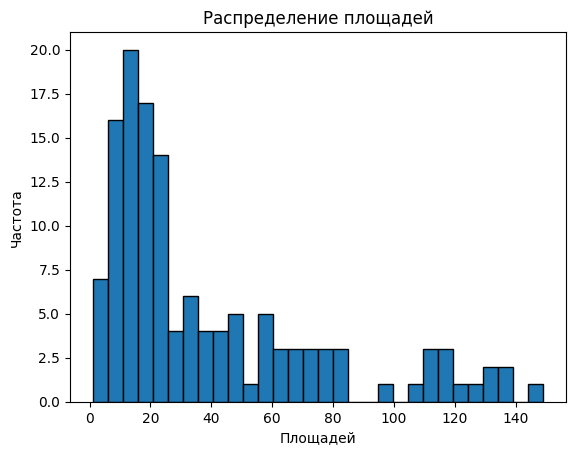

In [4]:
import pandas as pd

OUTPUT_FILE = r"C:\Users\Артур\.vscode\НОД\avito_commercial.csv"
df = pd.read_csv(OUTPUT_FILE).dropna()
#print(df)
df['price'] = df['price'].apply(int)
df = df[df['price'] < 500000]

def clean(line) -> str:
    if type(line) != float:
        line = line.split('м')[0].replace(',','.')
        return (float(line))
df['area'] = df['area'].apply(clean)
df= df[df['area'] < 150]

df = df.reset_index(drop=True)  
print(df)


import matplotlib.pyplot as plt

df['price'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Распределение цен')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()


df['area'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Распределение площадей')
plt.xlabel('Площадей')
plt.ylabel('Частота')
plt.show()

# Получение координат

In [5]:
import requests
def get_cords(address: str) ->dict[float]:
    url = url = "https://catalog.api.2gis.com/3.0/items/geocode"
    params = {
        "q": f"Москва, {address}",
        "fields": "items.point",
        "key": 'f75ecffb-2da9-4b54-8918-ce507a2f2a21',
    }
    resp = requests.get(url, params, timeout= 10 )
    data = resp.json()
    location = data['result']['items'][0]['point']
    return location

df['cords'] = df['address'].apply(get_cords)
print(df)



                                               title   price   area  \
0    10-118 м² в проходном месте на Тишинке в Москве  200000  118.0   
1                             Склад, 130 м² в Москве    1100  130.0   
2       Торговое помещение в аренду, 5.2 м² в Москве  150000    5.2   
3                             Офис, 58.8 м² в Москве   25000   58.8   
4            Свободного назначения, 57.6 м² в Москве  490000   57.6   
..                                               ...     ...    ...   
128                          Офис, 106.3 м² в Москве   49500  106.3   
129                             Офис, 15 м² в Москве   15000   15.0   
130                             Офис, 10 м² в Москве   40000   10.0   
131                           Офис, 23.4 м² в Москве   23400   23.4   
132                 Торговая площадь, 15 м² в Москве  190000   15.0   

                          address                   metro  metro_time  \
0    Большая Грузинская ул., 57с1             Белорусская   6–10 мин.   
1

In [10]:
def get_coverage_score(cords : dict[float]) -> int:
    lon = cords['lon']
    lat = cords['lat']
    delta = 0.005

    url = "https://opencellid.org/cell/getInArea"
    params = {
        "key":    "pk.70351fc8027e0d138edc47fa26789eae",  # ← ваш ключ
        "BBOX":   f"{lat-delta},{lon-delta},{lat+delta},{lon+delta}",
        "format": "json",
        "radio":  "LTE",
        "mcc":    250,
    }

    resp = requests.get(url, params=params, timeout=10)
    data = resp.json()

    if "error" in data:
        print(f"  [!] Ошибка API: {data}")
        return 0

    return data.get("count", 0)

# Тест
df['towers_nearby'] = df['cords'].apply(get_coverage_score)
print(df)

                                               title   price   area  \
0    10-118 м² в проходном месте на Тишинке в Москве  200000  118.0   
1                             Склад, 130 м² в Москве    1100  130.0   
2       Торговое помещение в аренду, 5.2 м² в Москве  150000    5.2   
3                             Офис, 58.8 м² в Москве   25000   58.8   
4            Свободного назначения, 57.6 м² в Москве  490000   57.6   
..                                               ...     ...    ...   
128                          Офис, 106.3 м² в Москве   49500  106.3   
129                             Офис, 15 м² в Москве   15000   15.0   
130                             Офис, 10 м² в Москве   40000   10.0   
131                           Офис, 23.4 м² в Москве   23400   23.4   
132                 Торговая площадь, 15 м² в Москве  190000   15.0   

                          address                   metro  metro_time  \
0    Большая Грузинская ул., 57с1             Белорусская   6–10 мин.   
1

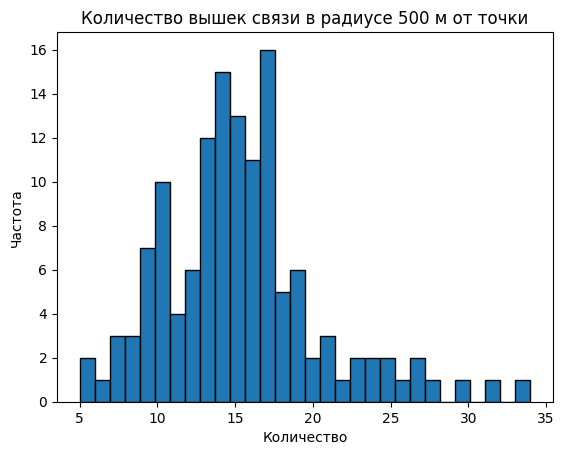

In [12]:
df['towers_nearby'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Количество вышек связи в радиусе 500 м от точки')
plt.xlabel('Количество')
plt.ylabel('Частота')
plt.show()

In [11]:
OUTPUT_FILE_1 = r"C:\Users\Артур\.vscode\НОД\locations.csv"

df.to_csv(OUTPUT_FILE_1, index=False, encoding="utf-8")
print(f"✓ Сохранено → {OUTPUT_FILE_1}")

✓ Сохранено → C:\Users\Артур\.vscode\НОД\locations.csv
